# MSE 5720 Assignment 2  
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---

## Introduction  



In [2]:
import os
import re
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [61]:
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[20, 30, 40, 50, 60, 70, 80, 90, 100]


In [62]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q1/A_Pre_Cal/energycutoff/si_{cutoff}/Si_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 20: Energy = -19.25618939 Ry
Cutoff 30: Energy = -19.25687729 Ry
Cutoff 40: Energy = -19.25699355 Ry
Cutoff 50: Energy = -19.25702285 Ry
Cutoff 60: Energy = -19.25704498 Ry
Cutoff 70: Energy = -19.25705342 Ry
Cutoff 80: Energy = -19.25706924 Ry
Cutoff 90: Energy = -19.25708139 Ry
Cutoff 100: Energy = -19.25708212 Ry

Energies collected:
ecutwfc = 20 Ry → total energy = -19.25618939
ecutwfc = 30 Ry → total energy = -19.25687729
ecutwfc = 40 Ry → total energy = -19.25699355
ecutwfc = 50 Ry → total energy = -19.25702285
ecutwfc = 60 Ry → total energy = -19.25704498
ecutwfc = 70 Ry → total energy = -19.25705342
ecutwfc = 80 Ry → total energy = -19.25706924
ecutwfc = 90 Ry → total energy = -19.25708139
ecutwfc = 100 Ry → total energy = -19.25708212


cutoffs: 9 [20, 30, 40, 50, 60, 70, 80, 90, 100]
energies: 9 [-19.25618939, -19.25687729, -19.25699355, -19.25702285, -19.25704498, -19.25705342, -19.25706924, -19.25708139, -19.25708212]


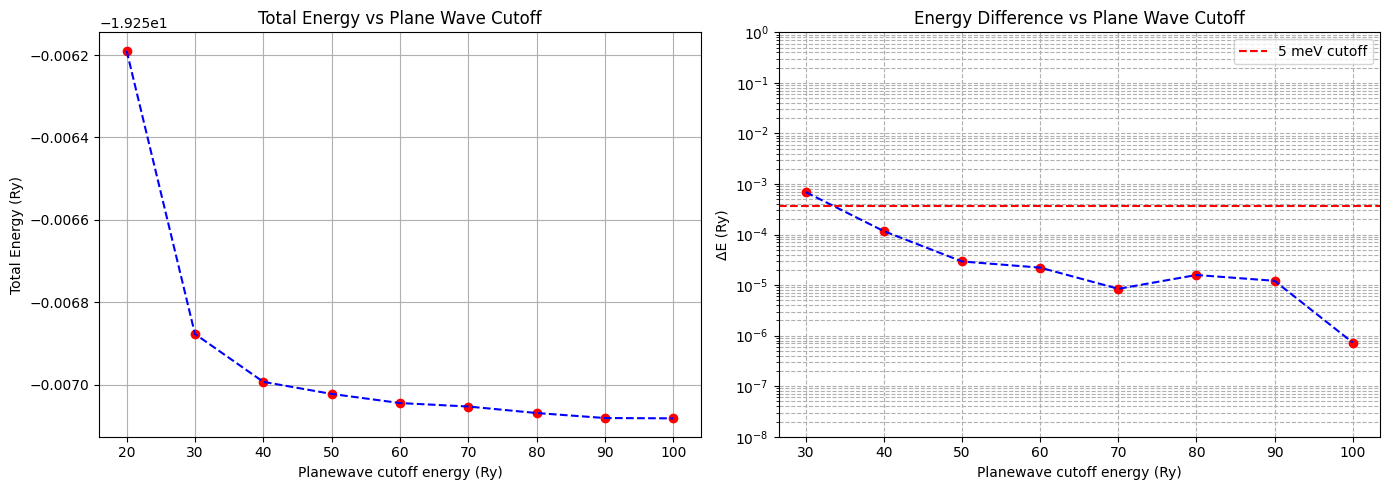

In [63]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [64]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [65]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [66]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/A_Pre_Cal/kpoints/si_k{k}/Si_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.075165
K-point 3: Total force = 0.063293
K-point 4: Total force = 0.059895
K-point 5: Total force = 0.058633
K-point 6: Total force = 0.058131
K-point 7: Total force = 0.057922
K-point 8: Total force = 0.057831
K-point 9: Total force = 0.05779
K-point 10: Total force = 0.057769
K-point 11: Total force = 0.057759
K-point 12: Total force = 0.057753


[None, 0.011871999999999994, 0.003398000000000005, 0.0012619999999999992, 0.0005019999999999955, 0.00020900000000000085, 9.10000000000008e-05, 4.099999999999937e-05, 2.1000000000000185e-05, 1.0000000000003062e-05, 5.999999999999062e-06]


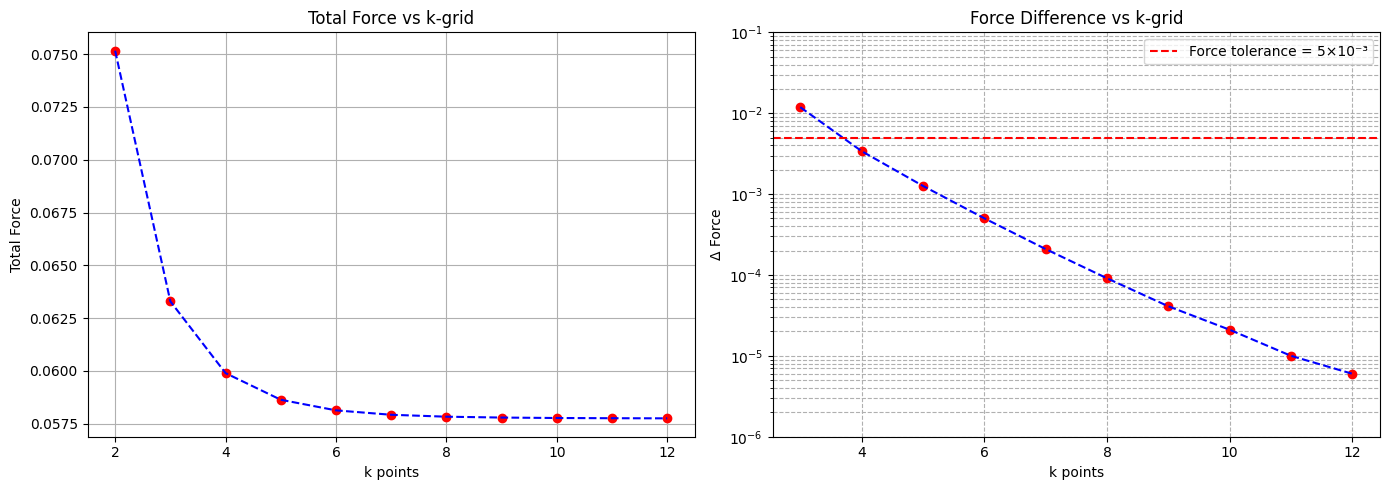

In [67]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

It can be deduced that the converged k point number is 6.

In [68]:
url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/Si.bandsplot.gnu"
response = requests.get(url)
if response.status_code != 200:
    raise RuntimeError(f"Failed to fetch data: {url}")

content = response.text.strip()

bands_raw = content.split("\n\n")

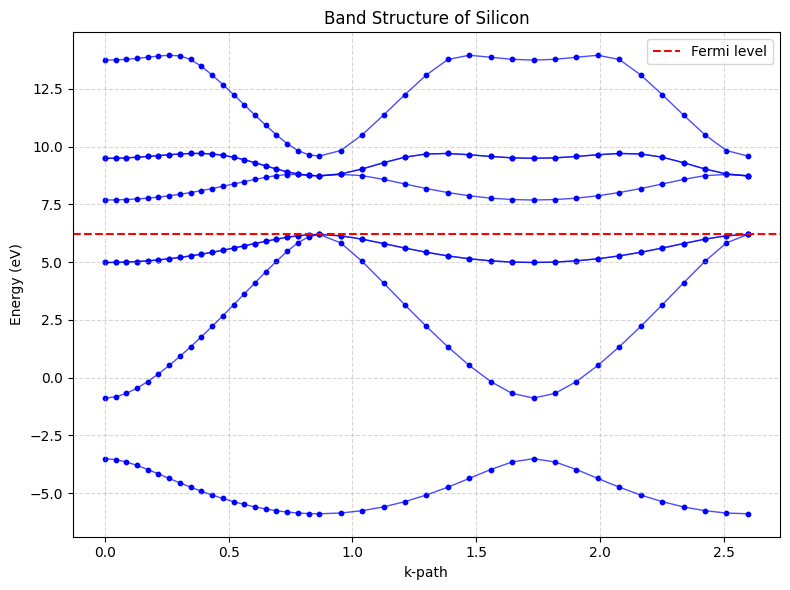

In [69]:
bands = []
for band in bands_raw:
    data = np.loadtxt(band.splitlines())
    k = data[:, 0]
    e = data[:, 1]
    bands.append((k, e))

plt.figure(figsize=(8, 6))

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

breaks = find_breaks([k for k, e in bands])

for k, e in bands:
    start_idx = 0
    for break_idx in breaks:
        end_idx = break_idx
        plt.scatter(k[start_idx:end_idx], e[start_idx:end_idx], s=10, color='blue')
        plt.plot(k[start_idx:end_idx], e[start_idx:end_idx], color='blue', linewidth=1, alpha=0.7)
        start_idx = end_idx
    
    # 绘制最后一段
    plt.scatter(k[start_idx:], e[start_idx:], s=10, color='blue')
    plt.plot(k[start_idx:], e[start_idx:], color='blue', linewidth=1, alpha=0.7)

plt.axhline(6.2002, color='red', linestyle='--', label='Fermi level')

plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("Band Structure of Silicon")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

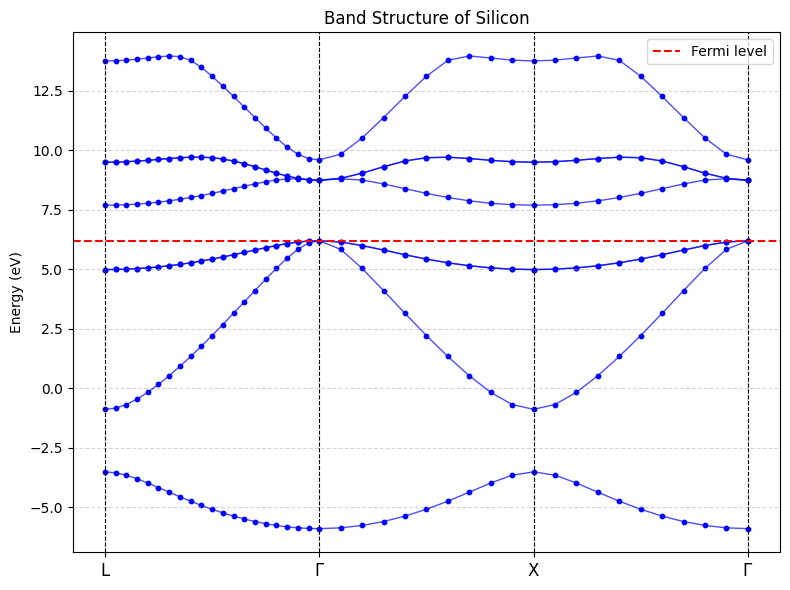

In [70]:
bands = []
for band in bands_raw:
    data = np.loadtxt(band.splitlines())
    k = data[:, 0]
    e = data[:, 1]
    bands.append((k, e))

plt.figure(figsize=(8, 6))

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

breaks = find_breaks([k for k, e in bands])

for k, e in bands:
    start_idx = 0
    for break_idx in breaks:
        end_idx = break_idx
        plt.scatter(k[start_idx:end_idx], e[start_idx:end_idx], s=10, color='blue')
        plt.plot(k[start_idx:end_idx], e[start_idx:end_idx], color='blue', linewidth=1, alpha=0.7)
        start_idx = end_idx

    plt.scatter(k[start_idx:], e[start_idx:], s=10, color='blue')
    plt.plot(k[start_idx:], e[start_idx:], color='blue', linewidth=1, alpha=0.7)

plt.axhline(6.2002, color='red', linestyle='--', label='Fermi level')

high_sym_points = [0, 0.86603, 1.73206, 2.5981]  # k轴位置
labels = ['L', r'$\Gamma$', 'X', r'$\Gamma$']

for x in high_sym_points:
    plt.axvline(x, color='black', linestyle='--', linewidth=0.8)

plt.xticks(high_sym_points, labels, fontsize=12)

plt.xlabel('')
plt.ylabel("Energy (eV)")
plt.title("Band Structure of Silicon")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


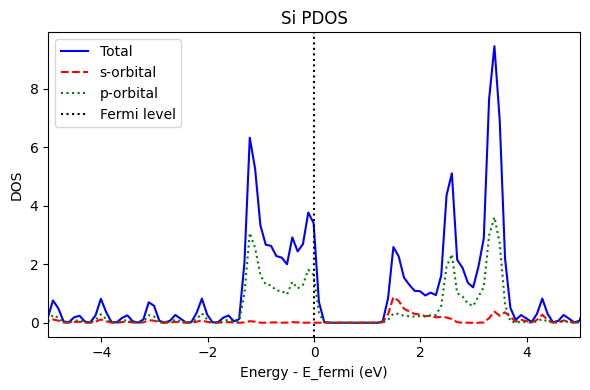

In [71]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/si_pdos.txt"
filename = "si_pdos.txt"
urllib.request.urlretrieve(url, filename)

data = np.loadtxt(filename, skiprows=1)

E = data[:,0]         
dos_total = data[:,1] 
ldos1 = data[:,2]     
ldos2 = data[:,3]    

E_fermi = 6.22
E_shifted = E - E_fermi

plt.figure(figsize=(6,4))
plt.plot(E_shifted, dos_total, label='Total', color='blue')
plt.plot(E_shifted, ldos1, label='s-orbital', color='red', linestyle='--')
plt.plot(E_shifted, ldos2, label='p-orbital', color='green', linestyle=':')
plt.axvline(0, color='k', linestyle=':', label='Fermi level')  # 标出费米能级
plt.xlabel("Energy - E_fermi (eV)")
plt.ylabel("DOS")
plt.title("Si PDOS")
plt.xlim(-5, 5)
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
cutoffs = list(range(30, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[30, 40, 50, 60, 70, 80, 90, 100]


In [76]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q1/D_Pre_Cal/Q1D_energyoff/Q1D_energyoff/bto_{cutoff}/BTO_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 30: Energy = -286.60179958 Ry
Cutoff 40: Energy = -286.62024856 Ry
Cutoff 50: Energy = -286.62198311 Ry
Cutoff 60: Energy = -286.62266744 Ry
Cutoff 70: Energy = -286.62115724 Ry
Cutoff 80: Energy = -286.61348506 Ry
Cutoff 90: Energy = -286.62051111 Ry
Cutoff 100: Energy = -286.62001962 Ry

Energies collected:
ecutwfc = 30 Ry → total energy = -286.60179958
ecutwfc = 40 Ry → total energy = -286.62024856
ecutwfc = 50 Ry → total energy = -286.62198311
ecutwfc = 60 Ry → total energy = -286.62266744
ecutwfc = 70 Ry → total energy = -286.62115724
ecutwfc = 80 Ry → total energy = -286.61348506
ecutwfc = 90 Ry → total energy = -286.62051111
ecutwfc = 100 Ry → total energy = -286.62001962


cutoffs: 8 [30, 40, 50, 60, 70, 80, 90, 100]
energies: 8 [-286.60179958, -286.62024856, -286.62198311, -286.62266744, -286.62115724, -286.61348506, -286.62051111, -286.62001962]


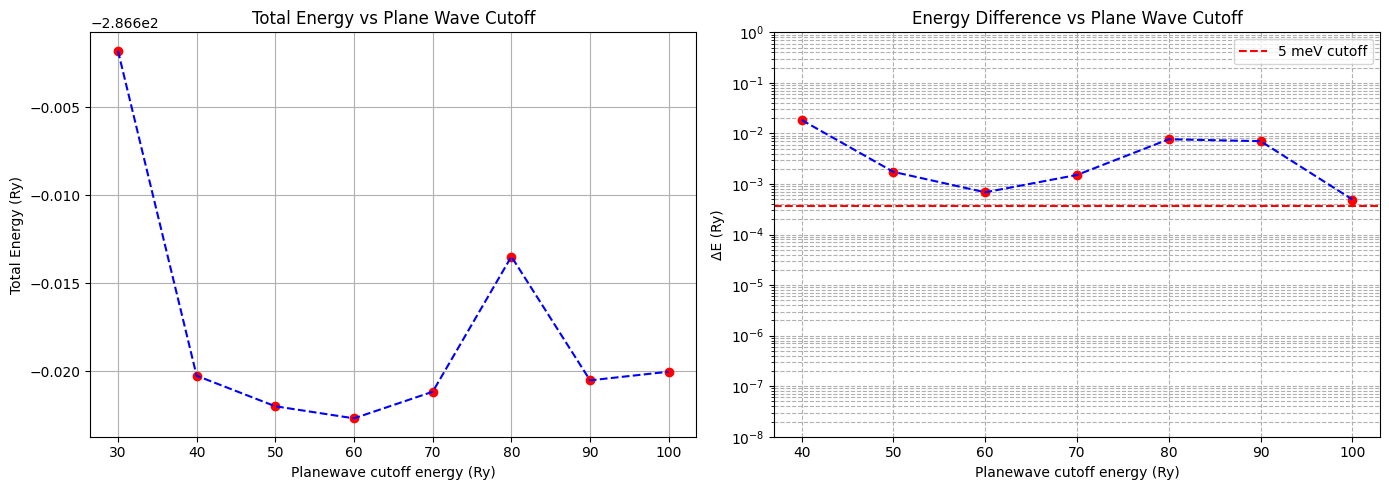

In [77]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [83]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [86]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [87]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/D_Pre_Cal/Q1D_kp/A2Q1D_kp/bto_k{k}/BTO_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.079494
K-point 3: Total force = 0.041894
K-point 4: Total force = 0.036431
K-point 5: Total force = 0.035485
K-point 6: Total force = 0.034604
K-point 7: Total force = 0.03472
K-point 8: Total force = 0.034583
K-point 9: Total force = 0.034712
K-point 10: Total force = 0.03458
K-point 11: Total force = 0.034595
K-point 12: Total force = 0.034509


[None, 0.037599999999999995, 0.005463000000000003, 0.0009459999999999955, 0.0008809999999999998, 0.00011599999999999805, 0.00013699999999999823, 0.00012899999999999717, 0.00013200000000000017, 1.5000000000001124e-05, 8.600000000000274e-05]


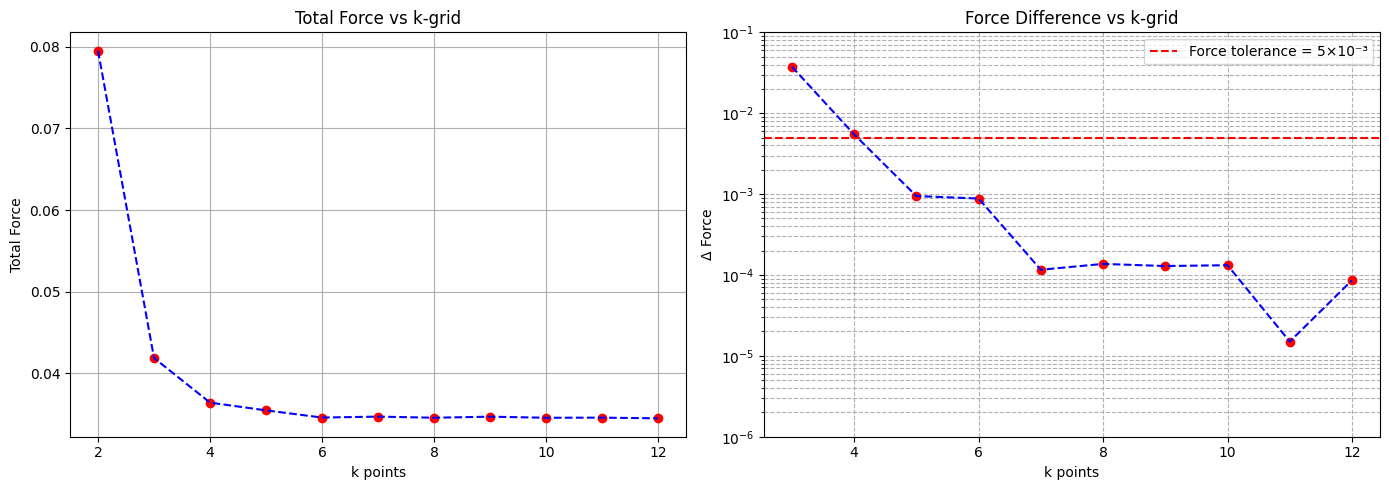

In [88]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

,deformation,eta,energy_Ry,volume_au3
0,isotropic,-0.006,-19.260196,260.5552
1,isotropic,-0.004,-19.260375,262.1311
2,isotropic,-0.002,-19.260488,263.7134
3,isotropic,0.000,-19.260536,265.3020
4,isotropic,0.002,-19.260522,266.8970
5,isotropic,0.004,-19.260447,268.4984
6,isotropic,0.006,-19.260310,270.1061
7,tetragonal,-0.006,-19.260345,265.2735
8,tetragonal,-0.004,-19.260452,265.2893
9,tetragonal,-0.002,-19.260516,265.2988


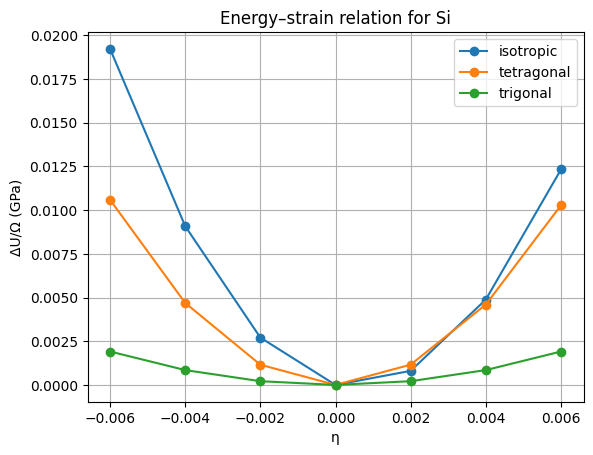

0.029762892384927516 0.01970299063749898 0.003608066293992124



### 🧾 Elastic Constants of Si (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    |   161.70 |
| C₁₂      | (2·A_iso −  A_tet·3)/3     |    65.09 |
| C₄₄      | 2·A_tri                     |   106.15 |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*


Results saved to Si_elastic_results_with_volume.csv


In [102]:
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import Markdown as md

# --- Basic Settings -----------------------------------------------------------
base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_si"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])
Ry_to_GPa = 14710.5  # conversion factor (Ry/bohr³ → GPa)

# --- Helper functions --------------------------------------------------------
def get_energy_and_volume(url: str):
    """Extract total energy and unit-cell volume from QE .out file hosted on GitHub."""
    r = requests.get(url)
    if r.status_code != 200:
        print(f"⚠️ Missing {url}")
        return np.nan, np.nan
    text = r.text

    # Total energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.]+)", text)
    energy = float(m_energy.group(1)) if m_energy else np.nan

    # Unit-cell volume
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.]+)", text)
    volume = float(m_vol.group(1)) if m_vol else np.nan

    return energy, volume

def fit_quadratic(x, y):
    """Fit y = A*x² and return coefficient A."""
    def f(x, A): return A * x**2
    popt, _ = curve_fit(f, x, y)
    return popt[0]

# --- Fetch all energies and volumes ------------------------------------------
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"Si_{defm}_{eta_dir}/Si_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V = get_energy_and_volume(url)
        records.append((defm, eta, E, V))

df = pd.DataFrame(records, columns=["deformation", "eta", "energy_Ry", "volume_au3"])
display(df)

# --- Fit ΔU/Ω vs η² ---------------------------------------------------------
slopes = {}
for defm in deformations:
    sub = df[df.deformation == defm].copy()
    E0 = sub.loc[sub.eta == 0, "energy_Ry"].values[0]
    V0 = sub.loc[sub.eta == 0, "volume_au3"].values[0]

    sub["dU_Ry"] = sub.energy_Ry - E0
    # ΔU / Ω using actual volume of each structure
    sub["dU_perVol"] = sub["dU_Ry"] / sub["volume_au3"]

    A = fit_quadratic(sub.eta, sub["dU_perVol"])
    slopes[defm] = A

    plt.plot(sub.eta, sub["dU_perVol"] * Ry_to_GPa, "o-", label=defm)

plt.xlabel("η")
plt.ylabel("ΔU/Ω (GPa)")
plt.title("Energy–strain relation for Si")
plt.grid(True)
plt.legend()
plt.show()

A_iso, A_tet, A_tri = slopes["isotropic"], slopes["tetragonal"], slopes["trigonal"]
print(A_iso, A_tet, A_tri)

C11 = Ry_to_GPa*(A_iso + A_tet) *2/ 9
C12 = Ry_to_GPa*(A_iso*2 - A_tet) / 9
C44 = 2 * A_tri * Ry_to_GPa

display(md(f"""
### 🧾 Elastic Constants of Si (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    | {C11:8.2f} |
| C₁₂      | (2·A_iso −  A_tet·3)/3     | {C12:8.2f} |
| C₄₄      | 2·A_tri                     | {C44:8.2f} |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*
"""))

df_out = df.copy()
df_out.to_csv("Si_elastic_results_with_volume.csv", index=False)
print("Results saved to Si_elastic_results_with_volume.csv")


,deformation,eta,energy_Ry,volume_au3
0,isotropic,-0.006,-22.665649,144.0002
1,isotropic,-0.004,-22.661673,144.8712
2,isotropic,-0.002,-22.657674,145.7456
3,isotropic,0.000,-22.653651,146.6236
4,isotropic,0.002,-22.649608,147.5051
5,isotropic,0.004,-22.645548,148.3902
6,isotropic,0.006,-22.641477,149.2787
7,tetragonal,-0.006,-22.653450,146.6079
8,tetragonal,-0.004,-22.653562,146.6166
9,tetragonal,-0.002,-22.653628,146.6219


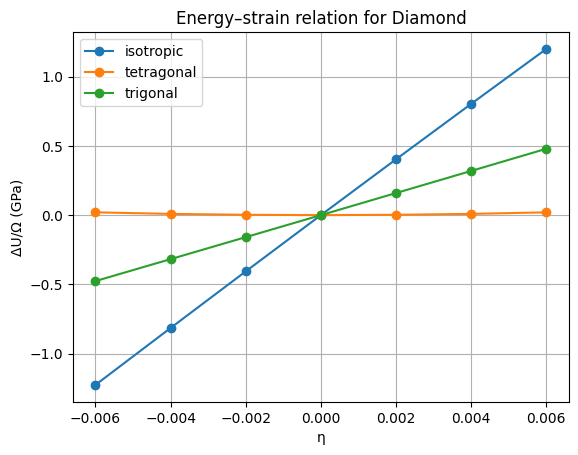

-0.024494514819934476 0.037891970916848365 0.0029197407950371265



### 🧾 Elastic Constants of Diamond (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    |    43.80 |
| C₁₂      | (2·A_iso −  A_tet·3)/3     |  -142.01 |
| C₄₄      | 2·A_tri                     |    85.90 |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*


Results saved to Diamond_elastic_results_with_volume.csv


In [6]:
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import Markdown as md

# --- Basic Settings -----------------------------------------------------------
base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])
Ry_to_GPa = 14710.5  # conversion factor (Ry/bohr³ → GPa)

# --- Helper functions --------------------------------------------------------
def get_energy_and_volume(url: str):
    """Extract total energy and unit-cell volume from QE .out file hosted on GitHub."""
    r = requests.get(url)
    if r.status_code != 200:
        print(f"⚠️ Missing {url}")
        return np.nan, np.nan
    text = r.text

    # Total energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.]+)", text)
    energy = float(m_energy.group(1)) if m_energy else np.nan

    # Unit-cell volume
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.]+)", text)
    volume = float(m_vol.group(1)) if m_vol else np.nan

    return energy, volume

def fit_quadratic(x, y):
    """Fit y = A*x² and return coefficient A."""
    def f(x, A): return A * x**2
    popt, _ = curve_fit(f, x, y)
    return popt[0]

# --- Fetch all energies and volumes ------------------------------------------
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"diamond_{defm}_{eta_dir}/diamond_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V = get_energy_and_volume(url)
        records.append((defm, eta, E, V))

df = pd.DataFrame(records, columns=["deformation", "eta", "energy_Ry", "volume_au3"])
display(df)

# --- Fit ΔU/Ω vs η² ---------------------------------------------------------
slopes = {}
for defm in deformations:
    sub = df[df.deformation == defm].copy()
    E0 = sub.loc[sub.eta == 0, "energy_Ry"].values[0]
    V0 = sub.loc[sub.eta == 0, "volume_au3"].values[0]

    sub["dU_Ry"] = sub.energy_Ry - E0
    # ΔU / Ω using actual volume of each structure
    sub["dU_perVol"] = sub["dU_Ry"] / sub["volume_au3"]

    A = fit_quadratic(sub.eta, sub["dU_perVol"])
    slopes[defm] = A

    plt.plot(sub.eta, sub["dU_perVol"] * Ry_to_GPa, "o-", label=defm)

plt.xlabel("η")
plt.ylabel("ΔU/Ω (GPa)")
plt.title("Energy–strain relation for Diamond")
plt.grid(True)
plt.legend()
plt.show()

A_iso, A_tet, A_tri = slopes["isotropic"], slopes["tetragonal"], slopes["trigonal"]
print(A_iso, A_tet, A_tri)

C11 = Ry_to_GPa*(A_iso + A_tet) *2/ 9
C12 = Ry_to_GPa*(A_iso*2 - A_tet) / 9
C44 = 2 * A_tri * Ry_to_GPa

display(md(f"""
### 🧾 Elastic Constants of Diamond (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    | {C11:8.2f} |
| C₁₂      | (2·A_iso −  A_tet·3)/3     | {C12:8.2f} |
| C₄₄      | 2·A_tri                     | {C44:8.2f} |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*
"""))

df_out = df.copy()
df_out.to_csv("Diamond_elastic_results_with_volume.csv", index=False)
print("Results saved to Diamond_elastic_results_with_volume.csv")


deformation    eta  energy_Ry  volume_au3                                                                                                                                                          url   status
  isotropic -0.006        NaN         NaN   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/Diamond_isotropic_etam0p006/Diamond_isotropic_etam0p006.out HTTP 404
  isotropic -0.004        NaN         NaN   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/Diamond_isotropic_etam0p004/Diamond_isotropic_etam0p004.out HTTP 404
  isotropic -0.002        NaN         NaN   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/Diamond_isotropic_etam0p002/Diamond_isotropic_etam0p002.out HTTP 404
  isotropic  0.000        NaN         NaN         https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/Diamond_isotropic_eta0p

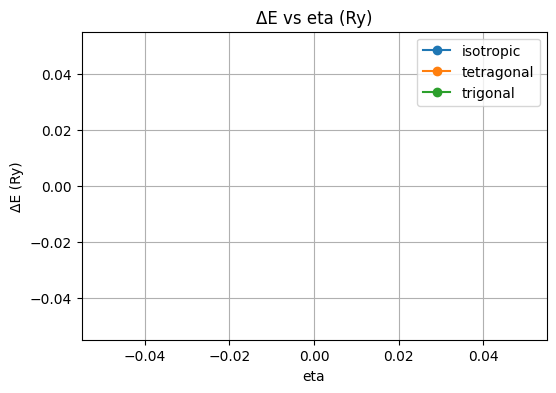

Skipping isotropic due to missing data
Skipping tetragonal due to missing data
Skipping trigonal due to missing data


In [ ]:
import re, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])

Ry_to_GPa = 14710.5

def get_energy_and_volume(url: str):
    r = requests.get(url)
    if r.status_code != 200:
        return np.nan, np.nan, f"HTTP {r.status_code}"
    text = r.text
    # energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.Eed+]+)", text)
    if m_energy:
        energy = float(m_energy.group(1))
    else:
        energy = np.nan
    # unit-cell volume (a.u.^3)
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.Eed+]+)", text)
    if m_vol:
        volume = float(m_vol.group(1))
    else:
        volume = np.nan
    return energy, volume, "OK"

# collect raw data
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"diamond_{defm}_{eta_dir}/diamond_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V, status = get_energy_and_volume(url)
        records.append((defm, eta, E, V, url, status))

df = pd.DataFrame(records, columns=["deformation","eta","energy_Ry","volume_au3","url","status"])
print(df.to_string(index=False))

# Quick checks
for defm in deformations:
    sub = df[df.deformation==defm].copy()
    print("\n=== DEFORMATION:", defm, "===")
    print("Statuses:", sub.status.unique())
    if sub.energy_Ry.isnull().any() or sub.volume_au3.isnull().any():
        print("⚠️ Missing energy or volume for some eta — check files!")
    # symmetry check E(eta) vs E(-eta)
    for eta in [0.002, 0.004, 0.006, 0.001]:
        if eta in sub.eta.values and (-eta) in sub.eta.values:
            E_p = sub.loc[sub.eta==eta, "energy_Ry"].values[0]
            E_m = sub.loc[sub.eta==-eta, "energy_Ry"].values[0]
            rel = (E_p - E_m)
            print(f" E(+{eta})-E(-{eta}) = {rel:.6e} Ry (should be ~0)")

# Plot raw ΔE (Ry) vs η
plt.figure(figsize=(6,4))
for defm in deformations:
    sub = df[df.deformation==defm].copy().sort_values("eta")
    E0 = sub.loc[sub.eta==0,"energy_Ry"].values
    if len(E0)==0:
        continue
    E0 = E0[0]
    sub["dE_Ry"] = sub.energy_Ry - E0
    plt.plot(sub.eta, sub.dE_Ry, "o-", label=defm)
plt.xlabel("eta")
plt.ylabel("ΔE (Ry)")
plt.title("ΔE vs eta (Ry)")
plt.grid(True)
plt.legend()
plt.show()

# Plot ΔE/V (Ry/au^3) vs eta and vs eta^2 and do fits
for defm in deformations:
    sub = df[df.deformation==defm].copy().sort_values("eta")
    if sub.energy_Ry.isnull().any() or sub.volume_au3.isnull().any():
        print(f"Skipping {defm} due to missing data")
        continue
    E0 = sub.loc[sub.eta==0,"energy_Ry"].values[0]
    sub["dE_Ry"] = sub.energy_Ry - E0
    sub["dE_perV"] = sub.dE_Ry / sub.volume_au3
    # plot vs eta
    plt.figure(figsize=(5,3))
    plt.plot(sub.eta, sub.dE_perV * Ry_to_GPa, "o-", label=f"{defm}")
    plt.xlabel("eta"); plt.ylabel("ΔE/V (GPa)")
    plt.title(f"{defm} ΔE/V vs eta")
    plt.grid(True)
    plt.show()
    # fit A*eta^2
    def f(x, A): return A * x**2
    popt, pcov = curve_fit(f, sub.eta, sub.dE_perV)
    A = popt[0]
    # linear-term test: fit B*eta + A*eta^2
    def g(x, B, A): return B*x + A*x**2
    popt2, _ = curve_fit(g, sub.eta, sub.dE_perV)
    B_lin = popt2[0]; A2 = popt2[1]
    print(f"{defm}: fitted A (eta^2) = {A:.6e} Ry/au^3; fitted linear B = {B_lin:.6e}")
    # show parity residuals: check odd part
    odd_part = []
    for eta in sub.eta.values:
        if -eta in sub.eta.values:
            E_p = sub.loc[sub.eta==eta,"dE_perV"].values[0]
            E_m = sub.loc[sub.eta==-eta,"dE_perV"].values[0]
            odd_part.append((E_p - E_m)/2)
    if odd_part:
        print(f" mean odd_part (should be ~0): {np.mean(odd_part):.3e} Ry/au^3")
    # plot fit vs data
    xs = np.linspace(sub.eta.min(), sub.eta.max(), 201)
    plt.figure(figsize=(5,3))
    plt.plot(sub.eta, sub.dE_perV*Ry_to_GPa, "o", label="data")
    plt.plot(xs, f(xs, A)*Ry_to_GPa, "-", label=f"A*eta^2 fit")
    plt.plot(xs, g(xs, B_lin, A2)*Ry_to_GPa, "--", label=f"B*eta + A*eta^2 fit")
    plt.xlabel("eta"); plt.ylabel("ΔE/V (GPa)")
    plt.title(f"{defm} fits")
    plt.legend(); plt.grid(True); plt.show()
